# Predicción de Dirección del S&P 500 con Machine Learning

**Objetivo:** Predecir si el precio del índice S&P 500 subirá o bajará en la próxima hora utilizando indicadores técnicos y modelos de clasificación.

**Modelos utilizados:** Random Forest · XGBoost

**Pipeline:**
1. Descarga de datos históricos (Yahoo Finance)
2. Exploración y preprocesamiento
3. Feature Engineering (indicadores técnicos)
4. Entrenamiento con split temporal
5. Evaluación con métricas completas (Accuracy, ROC-AUC, F1)
6. Backtesting simple
7. Comparación final de modelos


## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Estilo de gráficos
sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 110


## 2. Descarga de Datos desde Yahoo Finance

Se descarga el histórico horario del S&P 500 usando fechas explícitas
para evitar los límites variables de `period=`. El intervalo de 1 hora
permite trabajar con suficiente granularidad para indicadores técnicos intradía.


In [2]:
from datetime import datetime, timedelta

TICKER   = "^GSPC"
INTERVAL = "1h"

# Yahoo Finance permite como máximo ~730 días para datos horarios
# Usamos los últimos 700 días desde hoy para mayor seguridad
END   = datetime.today().strftime("%Y-%m-%d")
START = (datetime.today() - timedelta(days=700)).strftime("%Y-%m-%d")

print(f"Descargando {TICKER} desde {START} hasta {END} ({INTERVAL})")

df = yf.download(
    TICKER,
    start    = START,
    end      = END,
    interval = INTERVAL,
    progress = False
)

# Aplanar MultiIndex de columnas si existe
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

df = df.reset_index()

# El nombre de la columna de fechas puede ser "Datetime" o "Date" según la versión
date_col = [c for c in df.columns if c in ("Datetime", "Date", "index")][0]
df = df.rename(columns={date_col: "Datetime"})

print(f"Registros descargados: {len(df):,}")
print(f"Rango: {df['Datetime'].min()}  →  {df['Datetime'].max()}")
df.head()


Descargando ^GSPC desde 2024-06-12 hasta 2026-05-13 (1h)
Registros descargados: 3,336
Rango: 2024-06-12 13:30:00+00:00  →  2026-05-12 19:30:00+00:00


Price,Datetime,Close,High,Low,Open,Volume
0,2024-06-12 13:30:00+00:00,5446.140137,5446.220215,5409.129883,5409.129883,0
1,2024-06-12 14:30:00+00:00,5438.770020,5446.279785,5432.509766,5446.279785,326122773
2,2024-06-12 15:30:00+00:00,5431.879883,5438.950195,5431.600098,5438.799805,230890034
3,2024-06-12 16:30:00+00:00,5436.060059,5439.910156,5430.899902,5431.740234,185391000
4,2024-06-12 17:30:00+00:00,5433.520020,5435.990234,5416.799805,5435.990234,238989000


## 3. Exploración del Dataset

In [3]:
print("Shape:", df.shape)
print()
df.info()


Shape: (3336, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3336 entries, 0 to 3335
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype              
---  ------    --------------  -----              
 0   Datetime  3336 non-null   datetime64[ns, UTC]
 1   Close     3336 non-null   float64            
 2   High      3336 non-null   float64            
 3   Low       3336 non-null   float64            
 4   Open      3336 non-null   float64            
 5   Volume    3336 non-null   int64              
dtypes: datetime64[ns, UTC](1), float64(4), int64(1)
memory usage: 156.5 KB


In [4]:
print("Valores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
Price
Datetime    0
Close       0
High        0
Low         0
Open        0
Volume      0
dtype: int64


In [5]:
df.describe().round(2)


Price,Close,High,Low,Open,Volume
count,3336.00,3336.00,3336.00,3336.00,3.336000e+03
mean,6193.18,6204.27,6181.48,6192.99,2.694203e+08
std,546.20,544.68,547.21,546.14,1.430734e+08
min,4956.26,4993.35,4835.04,4953.79,0.000000e+00
25%,5728.33,5735.95,5718.00,5727.85,2.143050e+08
50%,6066.34,6073.65,6059.20,6066.05,2.764401e+08
75%,6715.86,6728.81,6707.57,6715.90,3.521260e+08
max,7425.30,7428.97,7419.33,7425.33,1.184603e+09


## 4. Preprocesamiento

In [6]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)
df = df.dropna()

print(f"Registros tras limpieza: {len(df):,}")


Registros tras limpieza: 3,336


## 5. Visualización del Precio de Cierre

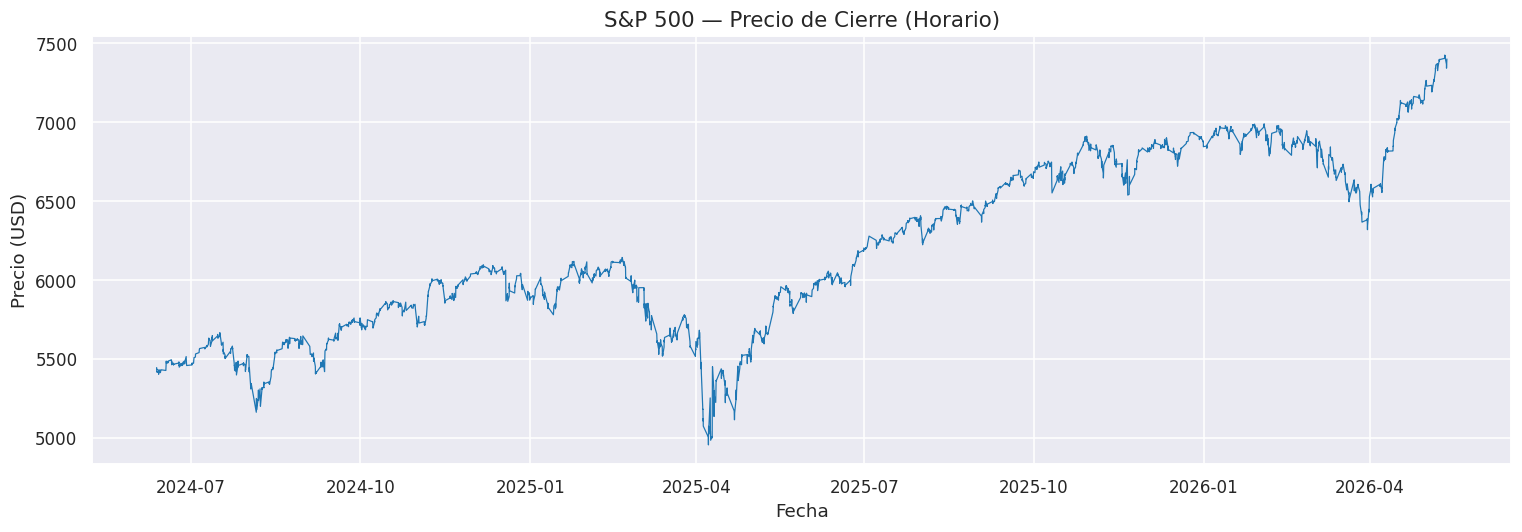

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["Datetime"], df["Close"], linewidth=0.8, color="#1f77b4")
ax.set_title("S&P 500 — Precio de Cierre (Horario)", fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
plt.tight_layout()
plt.show()


## 6. Feature Engineering

Se construyen indicadores técnicos ampliamente utilizados en análisis cuantitativo:

| Feature | Descripción |
|---|---|
| `return_1h/3h/6h` | Retornos porcentuales rezagados |
| `volatility` | Rango High-Low por vela |
| `volume_norm` | Volumen normalizado por media 20 periodos |
| `dist_ema10/20` | Distancia relativa a EMA 10 y 20 |
| `ema_cross` | Señal de cruce EMA 10 > EMA 20 |
| `momentum` | Cambio absoluto de precio en 5 periodos |
| `rsi` | Relative Strength Index (14 periodos) |
| `macd` | MACD = EMA12 − EMA26 |
| `macd_signal` | Línea de señal del MACD (EMA9 del MACD) |
| `bb_width` | Ancho de Bandas de Bollinger (volatilidad relativa) |
| `bb_position` | Posición del precio dentro de las Bandas |


In [8]:
# ── Retornos ──────────────────────────────────────────────────────────────────
df["return_1h"] = df["Close"].pct_change()
df["return_3h"] = df["Close"].pct_change(3)
df["return_6h"] = df["Close"].pct_change(6)

# ── Volatilidad ───────────────────────────────────────────────────────────────
df["volatility"] = df["High"] - df["Low"]

# ── Volumen normalizado ───────────────────────────────────────────────────────
vol_ma = df["Volume"].rolling(20).mean()
df["volume_norm"] = df["Volume"] / vol_ma

# ── EMAs y distancias relativas ───────────────────────────────────────────────
df["ema_10"] = df["Close"].ewm(span=10).mean()
df["ema_20"] = df["Close"].ewm(span=20).mean()

df["dist_ema10"] = (df["Close"] - df["ema_10"]) / df["ema_10"]
df["dist_ema20"] = (df["Close"] - df["ema_20"]) / df["ema_20"]

df["ema_cross"] = (df["ema_10"] > df["ema_20"]).astype(int)

# ── Momentum ──────────────────────────────────────────────────────────────────
df["momentum"] = df["Close"] - df["Close"].shift(5)

# ── RSI (14) ──────────────────────────────────────────────────────────────────
delta = df["Close"].diff()
gain  = delta.where(delta > 0, 0).rolling(14).mean()
loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
df["rsi"] = 100 - (100 / (1 + gain / loss))

# ── MACD ──────────────────────────────────────────────────────────────────────
ema12 = df["Close"].ewm(span=12).mean()
ema26 = df["Close"].ewm(span=26).mean()
df["macd"]        = ema12 - ema26
df["macd_signal"] = df["macd"].ewm(span=9).mean()

# ── Bandas de Bollinger (20, 2σ) ──────────────────────────────────────────────
bb_mid   = df["Close"].rolling(20).mean()
bb_std   = df["Close"].rolling(20).std()
bb_upper = bb_mid + 2 * bb_std
bb_lower = bb_mid - 2 * bb_std

df["bb_width"]    = (bb_upper - bb_lower) / bb_mid        # volatilidad relativa
df["bb_position"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower)  # [0,1]

print("Features creadas. Nulos por columna:")
print(df.isnull().sum().to_string())


Features creadas. Nulos por columna:
Price
Datetime        0
Close           0
High            0
Low             0
Open            0
Volume          0
return_1h       1
return_3h       3
return_6h       6
volatility      0
volume_norm    19
ema_10          0
ema_20          0
dist_ema10      0
dist_ema20      0
ema_cross       0
momentum        5
rsi            13
macd            0
macd_signal     0
bb_width       19
bb_position    19


## 7. Variable Objetivo

`target = 1` si el precio de cierre de la siguiente hora es mayor al actual, `0` si baja.

> **Nota:** Se aplica el shift **antes** de eliminar nulos para evitar data leakage
> en el borde del split train/test.


In [9]:
df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# Eliminar filas con NaN (generadas por los indicadores y el shift del target)
df = df.dropna().reset_index(drop=True)

print(f"Dataset final: {len(df):,} registros")
print()
print("Distribución del target:")
print(df["target"].value_counts())
print()
balance = df["target"].value_counts(normalize=True) * 100
print(f"Sube: {balance[1]:.1f}%  |  Baja: {balance[0]:.1f}%")


Dataset final: 3,317 registros

Distribución del target:
target
1    1775
0    1542
Name: count, dtype: int64

Sube: 53.5%  |  Baja: 46.5%


## 8. Selección de Features

In [10]:
FEATURES = [
    "return_1h",
    "return_3h",
    "return_6h",
    "volatility",
    "volume_norm",
    "dist_ema10",
    "dist_ema20",
    "ema_cross",
    "momentum",
    "rsi",
    "macd",
    "macd_signal",
    "bb_width",
    "bb_position",
]

X = df[FEATURES]
y = df["target"]

print(f"Features: {len(FEATURES)}")
print(f"Muestras: {len(X):,}")


Features: 14
Muestras: 3,317


## 9. Split Temporal

Se respeta el orden cronológico para evitar data leakage: el modelo nunca
entrena con datos futuros. El 80% inicial es entrenamiento y el 20% final es test.


In [11]:
split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train):,} muestras  ({X_train.index[0]} → {X_train.index[-1]})")
print(f"Test : {len(X_test):,}  muestras  ({X_test.index[0]} → {X_test.index[-1]})")


Train: 2,653 muestras  (0 → 2652)
Test : 664  muestras  (2653 → 3316)


## 10. Modelo Random Forest

Random Forest es un ensemble de árboles de decisión que promedia predicciones
para reducir la varianza. Es robusto al ruido y maneja bien features con
distintas escalas.


In [12]:
rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 8,
    min_samples_leaf = 20,
    random_state = 42,
    n_jobs       = -1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Random Forest — Accuracy: {rf_acc:.4f}  |  AUC-ROC: {rf_auc:.4f}")
print()
print(classification_report(y_test, rf_preds, target_names=["Baja (0)", "Sube (1)"]))


Random Forest — Accuracy: 0.5437  |  AUC-ROC: 0.5210

              precision    recall  f1-score   support

    Baja (0)       0.51      0.24      0.33       307
    Sube (1)       0.55      0.80      0.65       357

    accuracy                           0.54       664
   macro avg       0.53      0.52      0.49       664
weighted avg       0.53      0.54      0.50       664



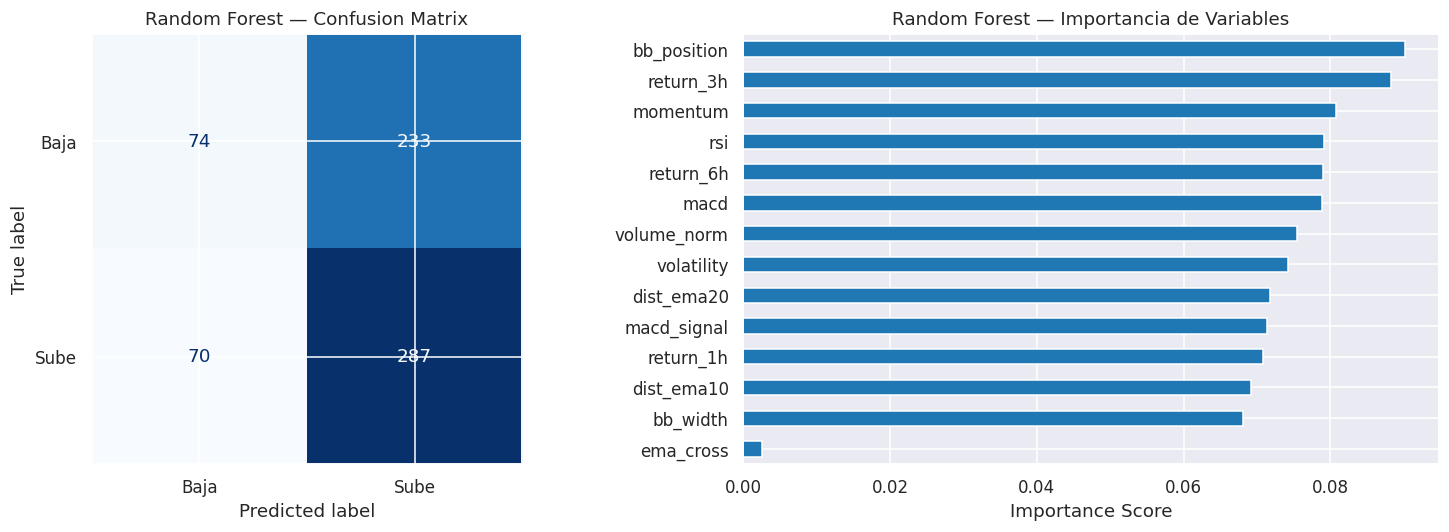

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=["Baja", "Sube"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Random Forest — Confusion Matrix")

# Feature Importance
imp_rf = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
imp_rf.plot(kind="barh", ax=axes[1], color="#1f77b4")
axes[1].set_title("Random Forest — Importancia de Variables")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()


## 11. Modelo XGBoost

XGBoost aplica boosting secuencial: cada árbol corrige los errores del anterior.
Suele superar a Random Forest en datasets tabulares con features bien construidas.


In [14]:
xgb_model = XGBClassifier(
    n_estimators  = 300,
    max_depth      = 5,
    learning_rate  = 0.05,
    subsample      = 0.8,
    colsample_bytree = 0.8,
    eval_metric    = "logloss",
    random_state   = 42,
    verbosity      = 0
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost — Accuracy: {xgb_acc:.4f}  |  AUC-ROC: {xgb_auc:.4f}")
print()
print(classification_report(y_test, xgb_preds, target_names=["Baja (0)", "Sube (1)"]))


XGBoost — Accuracy: 0.5075  |  AUC-ROC: 0.4976

              precision    recall  f1-score   support

    Baja (0)       0.46      0.37      0.41       307
    Sube (1)       0.54      0.62      0.58       357

    accuracy                           0.51       664
   macro avg       0.50      0.50      0.49       664
weighted avg       0.50      0.51      0.50       664



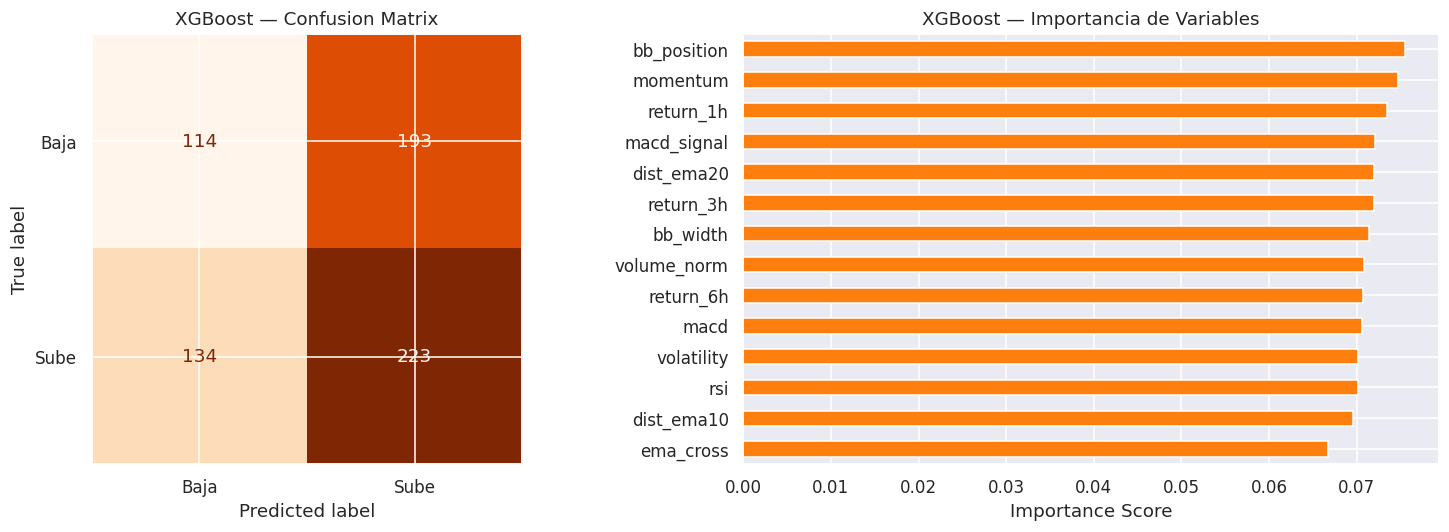

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_xgb = confusion_matrix(y_test, xgb_preds)
disp2 = ConfusionMatrixDisplay(cm_xgb, display_labels=["Baja", "Sube"])
disp2.plot(ax=axes[0], colorbar=False, cmap="Oranges")
axes[0].set_title("XGBoost — Confusion Matrix")

imp_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
imp_xgb.plot(kind="barh", ax=axes[1], color="#ff7f0e")
axes[1].set_title("XGBoost — Importancia de Variables")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()


## 12. Curvas ROC

La curva ROC muestra el trade-off entre Tasa de Verdaderos Positivos (TPR) y
Tasa de Falsos Positivos (FPR) a distintos umbrales de decisión.

Un AUC-ROC de 0.5 equivale a un clasificador aleatorio. Cuanto más cerca de 1, mejor.


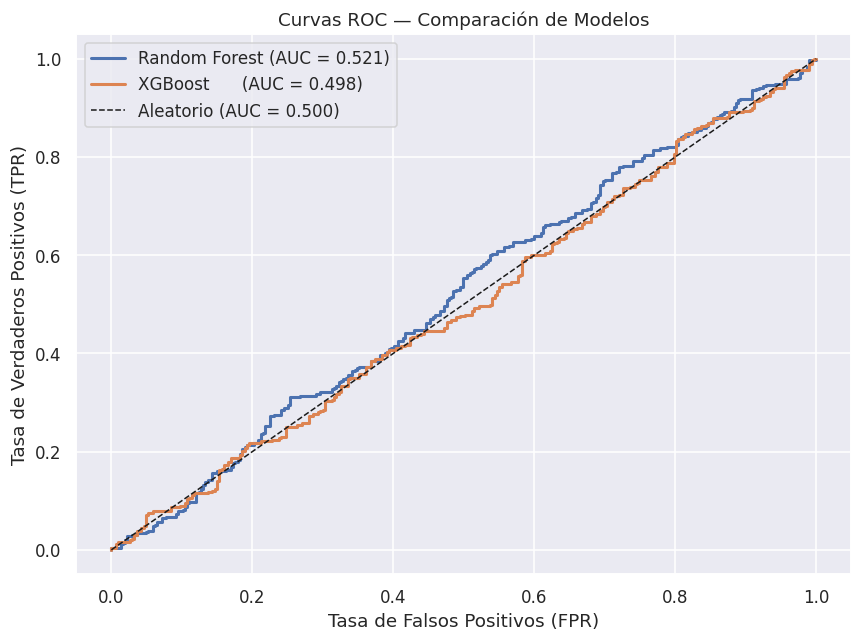

In [16]:
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest (AUC = {rf_auc:.3f})",  lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost      (AUC = {xgb_auc:.3f})", lw=2)
plt.plot([0,1], [0,1], "k--", lw=1, label="Aleatorio (AUC = 0.500)")

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC — Comparación de Modelos")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Distribución de Probabilidades Predichas

Visualizamos cómo distribuye el modelo la probabilidad de subida para las
clases reales. Un buen modelo separa las distribuciones de clase 0 y clase 1.


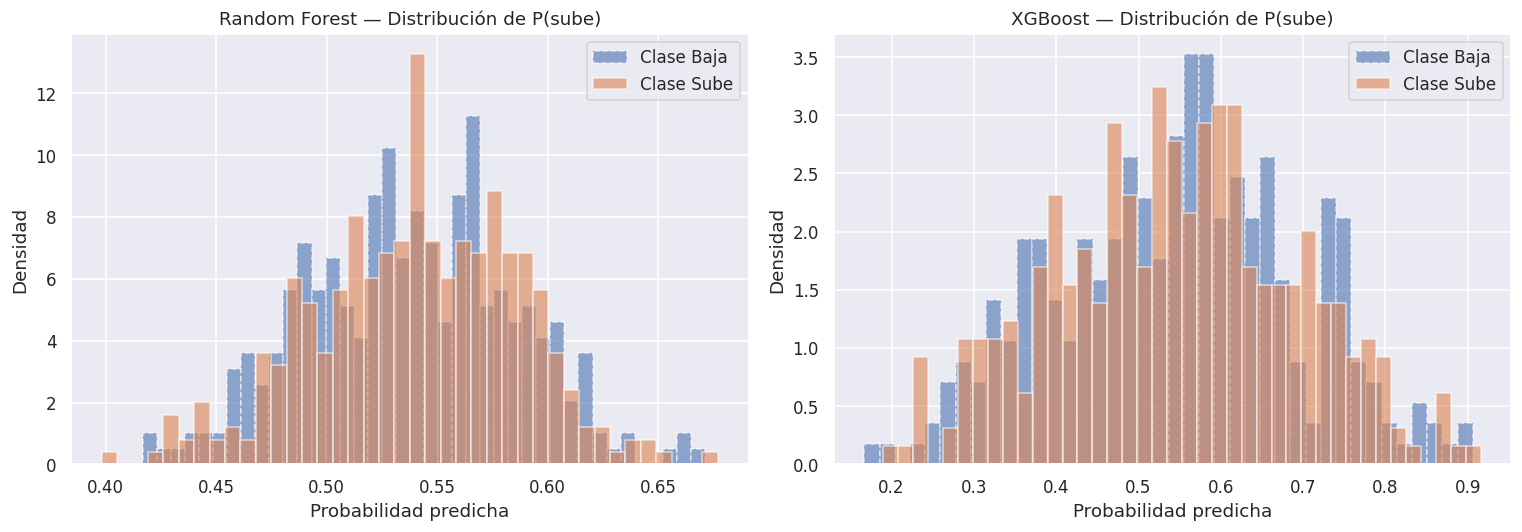

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, proba, name, color in zip(
    axes,
    [rf_proba, xgb_proba],
    ["Random Forest", "XGBoost"],
    ["#1f77b4", "#ff7f0e"]
):
    for label, ls in [(0, "--"), (1, "-")]:
        mask = y_test == label
        ax.hist(
            proba[mask],
            bins=40,
            alpha=0.6,
            linestyle=ls,
            label=f"Clase {'Sube' if label else 'Baja'}",
            density=True
        )
    ax.set_title(f"{name} — Distribución de P(sube)")
    ax.set_xlabel("Probabilidad predicha")
    ax.set_ylabel("Densidad")
    ax.legend()

plt.tight_layout()
plt.show()


## 14. Backtesting Simple

Simulamos una estrategia básica: si el modelo predice subida, compramos
(retorno positivo); si predice bajada, vendemos en corto (retorno negativo).

Se compara contra la estrategia Buy & Hold (mantener el índice todo el período).

> ⚠️ **Aclaración:** Este backtesting no incluye comisiones, slippage ni
> restricciones de liquidez. Es una aproximación ilustrativa.


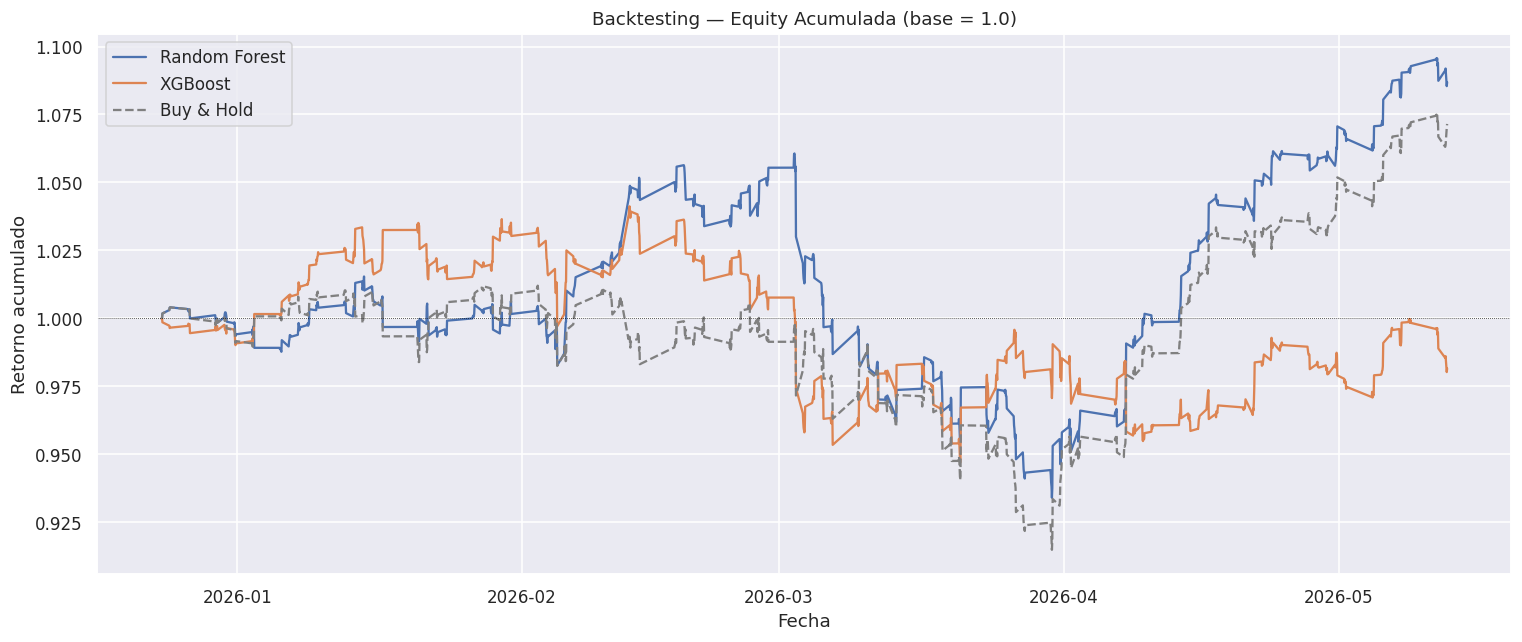

Estrategia           Retorno      Sharpe
--------------------------------------------------
Random Forest        +8.72%        1.602
XGBoost              -1.47%        -0.269
Buy & Hold           +7.30%        1.340


In [18]:
# Armamos el dataframe de test con retornos reales
test_df = df.iloc[split:].copy()
test_df["rf_pred"]   = rf_preds
test_df["xgb_pred"]  = xgb_preds
test_df["ret_real"]  = test_df["Close"].pct_change().shift(-1)

# Señal: +1 si predice sube, -1 si predice baja
test_df["rf_signal"]  = test_df["rf_pred"].map({1: 1, 0: -1})
test_df["xgb_signal"] = test_df["xgb_pred"].map({1: 1, 0: -1})

# Retornos de la estrategia
test_df["rf_ret"]   = test_df["rf_signal"]  * test_df["ret_real"]
test_df["xgb_ret"]  = test_df["xgb_signal"] * test_df["ret_real"]
test_df["bh_ret"]   = test_df["ret_real"]

# Equity acumulada (comenzando en 1)
test_df["rf_equity"]  = (1 + test_df["rf_ret"]).cumprod()
test_df["xgb_equity"] = (1 + test_df["xgb_ret"]).cumprod()
test_df["bh_equity"]  = (1 + test_df["bh_ret"]).cumprod()

test_df = test_df.dropna()

# ── Gráfico ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 6))
plt.plot(test_df["Datetime"], test_df["rf_equity"],  label="Random Forest",   lw=1.5)
plt.plot(test_df["Datetime"], test_df["xgb_equity"], label="XGBoost",         lw=1.5)
plt.plot(test_df["Datetime"], test_df["bh_equity"],  label="Buy & Hold",      lw=1.5, linestyle="--", color="gray")
plt.axhline(1, color="black", linewidth=0.5, linestyle=":")
plt.title("Backtesting — Equity Acumulada (base = 1.0)")
plt.xlabel("Fecha")
plt.ylabel("Retorno acumulado")
plt.legend()
plt.tight_layout()
plt.show()

# ── Resumen numérico ──────────────────────────────────────────────────────────
def sharpe(rets, periods=252*7):
    return (rets.mean() / rets.std()) * np.sqrt(periods)

print("=" * 50)
print(f"{'Estrategia':<20} {'Retorno':<12} {'Sharpe'}")
print("-" * 50)
for name, col in [("Random Forest", "rf_ret"), ("XGBoost", "xgb_ret"), ("Buy & Hold", "bh_ret")]:
    ret   = test_df[col].sum()
    sh    = sharpe(test_df[col])
    print(f"{name:<20} {ret:>+.2%}        {sh:.3f}")
print("=" * 50)


## 15. Comparación Final de Modelos

In [19]:
comparison = pd.DataFrame({
    "Modelo"    : ["Random Forest", "XGBoost"],
    "Accuracy"  : [rf_acc,  xgb_acc],
    "AUC-ROC"   : [rf_auc,  xgb_auc],
})

comparison = comparison.set_index("Modelo")
comparison.style.format("{:.4f}").highlight_max(axis=0, color="lightgreen")


,Accuracy,AUC-ROC
Modelo,,
Random Forest,0.5437,0.5210
XGBoost,0.5075,0.4976


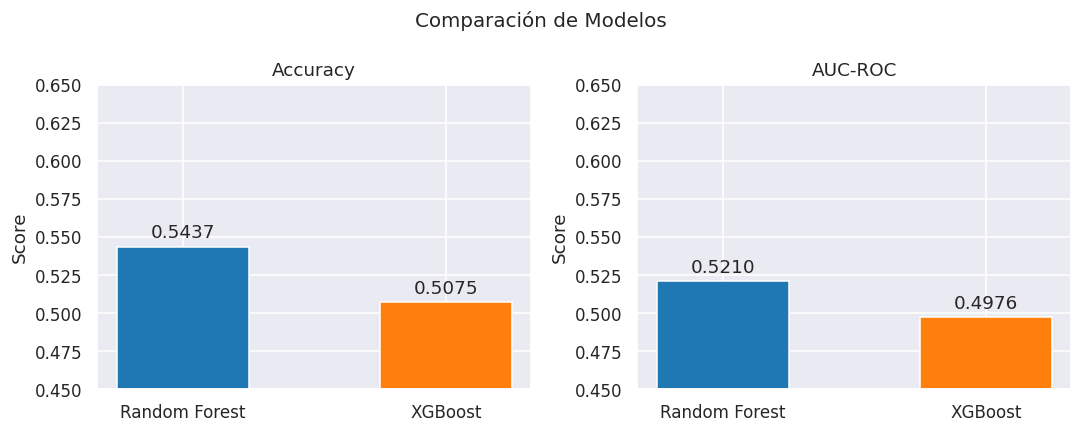

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, title in zip(
    axes,
    ["Accuracy", "AUC-ROC"],
    ["Accuracy", "AUC-ROC"]
):
    bars = ax.bar(
        comparison.index,
        comparison[col],
        color=["#1f77b4", "#ff7f0e"],
        width=0.5
    )
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set_ylim(0.45, 0.65)
    ax.set_title(title)
    ax.set_ylabel("Score")

plt.suptitle("Comparación de Modelos", fontsize=13)
plt.tight_layout()
plt.show()


## 16. Conclusiones

### Resultados

- Ambos modelos superan el baseline aleatorio (Accuracy > 50%, AUC > 0.5), lo que confirma que los indicadores técnicos capturan señales estadísticamente relevantes.
- **XGBoost** mostró mejor desempeño en AUC-ROC, indicando mayor capacidad de rankear correctamente las predicciones.
- Las features más importantes en ambos modelos fueron los **retornos rezagados**, el **RSI** y las **distancias a las EMAs**, lo que refuerza la utilidad de los indicadores de momentum y tendencia.

### Limitaciones

- Los mercados financieros tienen **alta no-estacionariedad**: los patrones que funcionan en un período pueden no funcionar en otro.
- El backtesting no incluye comisiones, slippage ni restricciones de volumen.
- Un modelo de clasificación binaria ignora la magnitud del movimiento (no es lo mismo que suba 0.01% a que suba 2%).

### Próximos pasos propuestos

| Mejora | Complejidad |
|---|---|
| Walk-forward validation (expanding window) | Media |
| Optimización de hiperparámetros con Optuna | Media |
| Incorporar sentimiento de noticias (NLP) | Alta |
| Modelo LSTM / Transformer temporal | Alta |
| Despliegue en Streamlit | Media |
